### Scrap notebook for testing and plotting

In [1]:
from astropy.cosmology import Planck18
%env XLA_PYTHON_CLIENT_ALLOCATOR=platform
import astropy.units as u
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from glob import glob
import lalsimulation as lalsim
import numpy as np
import os.path as op
import sys
import pandas as pd
sys.path.append('../src/')
import jax.numpy as jnp
import h5py
from tqdm import tqdm, trange
import weighting
from scipy import stats
import intensity_models
import fisher_snrs
import matplotlib.pyplot as plt
from tqdm import tqdm
import mock_observations
import intensity_models
from scipy import special
from gwosc.api import fetch_event_json

import re
import os
from scipy.interpolate import RegularGridInterpolator
import jax
from importlib import reload 
reload(fisher_snrs)
jax.local_devices()
jax.config.update("jax_enable_x64", True)


env: XLA_PYTHON_CLIENT_ALLOCATOR=platform


/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_pop_params(config_file):
    population_parameters = dict()
    population_parameters = dict()
    with open(config_file) as param_file:
        for line in param_file:
            (key, val) = line.split('=')
            population_parameters[key.strip()] = val.strip()
            try:
                population_parameters[key.strip()] = float(val.strip())
            except ValueError:
                pass
    cosmo = intensity_models.FlatwCDMCosmology(population_parameters['h'], population_parameters['Om'],
                                           population_parameters['w'], population_parameters['zmax'])

    return population_parameters, cosmo


def get_mock_obs(df, out_file, cosmo, mult=1, detection_threshold=8, jitter_SNR=True, ndet=1):
    """
    takes in an event dataframe df and generates a file which will store the values we'd actulaly observe from the events

    inputs
        df: events 
        out_file: where to store the observed values
        cosmo: cosmology model we're using, usually FlatwCDMCosmology with population paramters
        mult: multiplier on the paramter uncertatintes, so higher numbers scale all the uncertainties up (except SNR)
        detection_threshold: what SNR we cut on, 8 by default
        jitter_SNR: False if detection is perfect, otherwise should be on
        ndet: number of mock detectors, controls how much we jitter the SNR by
    
    outputs a file with observed log chirp mass, log q, and Theta (finn-chernoff parameter) with corresponding uncertainties calculted from 
    SNR scalings
    """
    rng = np.random.default_rng(251286134409181405721219170031242732711)
    jitter= rng.normal(loc=0, scale=np.sqrt(ndet), size=len(df))
    if jitter_SNR:
        df['SNR_OBS'] = df['SNR'] +jitter # rng.normal(loc=0, scale=np.sqrt(ndet), size=len(df))#size=len(inj))
    else:
        df['SNR_OBS'] = df['SNR']
    
    inj_det = df[df['SNR_OBS'] > detection_threshold].copy()
    inj_det['mc'] = inj_det['m1'] * (inj_det['q']**(3/5) / ((1 + inj_det['q'])**(1/5)))
    inj_det['dl'] = cosmo.dL(np.array(inj_det['z'].tolist()))
    inj_det['mc_det'] = inj_det['mc'] * (1 + inj_det['z'])
    log_mc_obs = []
    sigma_log_mc = []
    log_q_obs=[]
    sigma_log_q=[]
    theta_obs=[]
    sigma_theta=[]
    for i, row in tqdm(inj_det.iterrows()):
        uncert = mock_observations.Uncertainties.from_snr(row['SNR_OBS'])
        log_mc_obs.append(np.log(row['mc_det']) + mult*uncert.sigma_log_mc*rng.normal())
        sigma_log_mc.append(mult*uncert.sigma_log_mc)
        
        slq = mult*uncert.sigma_q / row['q']   # error propagation
        b = (0.0 - np.log(row['q'])) / slq
        log_q_obs.append(truncnorm.rvs(-np.inf, b, loc=np.log(row['q']), scale=slq))
        sigma_log_q.append(slq)
    
        sigma_theta.append(mult*uncert.sigma_theta)
        # Θ_obs ~ N[0, 0.25](Θ_true, σΘ),
        # modeled after DOI 10.3847/2041-8213/ab77c9
        a = (0.0 - row['Theta']) / sigma_theta[-1]
        b = (1 - row['Theta']) / sigma_theta[-1]
        theta_obs.append(truncnorm.rvs(a, b, loc=row['Theta'], scale= sigma_theta[-1]))
    
    inj_det['log_mc_obs'] = log_mc_obs
    inj_det['sigma_log_mc'] = sigma_log_mc
    
    inj_det['log_q_obs'] = log_q_obs
    inj_det['sigma_log_q'] = sigma_log_q
    inj_det['theta_obs'] = theta_obs
    inj_det['sigma_theta'] = sigma_theta
    
    inj_det['z'] = inj_det['z']
    inj_det = inj_det.reset_index(drop=True)
    inj_det['evt'] = [f'evt_{i:04d}' for i in inj_det.index]
    inj_det.to_hdf(out_file, key='observations')


In [3]:
SENSITIVITIES = {'aligo': lalsim.SimNoisePSDaLIGODesignSensitivityP1200087,
                'aplus': lalsim.SimNoisePSDaLIGOAPlusDesignSensitivityT1800042,
                'CE': lalsim.SimNoisePSDCosmicExplorerP1600143}


grid2 = np.load("snr_grid_326.npz")

m1_grid2  = grid2["m1_grid"]
q_grid2   = grid2["q_grid"]
snr_grid2 = grid2["snr_grid"]
dL_fid2   = float(grid2["dL_fid"])

log_snr_interp2 = RegularGridInterpolator((m1_grid2, q_grid2), np.log(snr_grid2), bounds_error=False, fill_value=-np.inf)

/tmp/ipykernel_1084379/3837369951.py:13: RuntimeWarning: divide by zero encountered in log
  log_snr_interp2 = RegularGridInterpolator((m1_grid2, q_grid2), np.log(snr_grid2), bounds_error=False, fill_value=-np.inf)


In [10]:
population_parameters, cosmo_true = get_pop_params('../reproduce/configs/c2_zp5.txt')

sel_samples = pd.read_hdf('../src/sel_c2_zm55_cut.h5', key='true_parameters')
ndraw = sel_samples['ndraw'].iloc[0]

zs_sel = cosmo_true.z_of_dL(sel_samples['dl'].values)
m1s_sel = sel_samples['m1d'].values / (1 + zs_sel)

log_dN_true = intensity_models.build_population_model(population_parameters)  # at true params

log_sel_wts = (log_dN_true(m1s_sel, sel_samples['q'].values, zs_sel)
               - np.log(sel_samples['pdraw_sel'].values)
               - 2*np.log1p(zs_sel)
               + np.log(cosmo_true.dVCdz(zs_sel))
               - np.log(cosmo_true.ddL_dz(zs_sel)))

#mu_sel_true = np.exp(jss.logsumexp(log_sel_wts) - np.log(ndraw))

#nobs = len(pd.read_hdf('../src/pe_c2_zm55_cut.h5', key='samples'))
#R_true = nobs / mu_sel_true

In [11]:
mu_sel_true = np.exp(special.logsumexp(log_sel_wts) - np.log(ndraw))

nobs = len(pd.read_hdf('../src/pe_c2_zm55_cut.h5', key='samples'))
R_true = nobs / mu_sel_true

In [3]:
data_paths = ['/mnt/home/ccalvk/ceph/GWTC-3/IGWN-GWTC3p0-v2-GW*_PEDataRelease_mixed_nocosmo.h5',

            '/mnt/home/ccalvk/ceph/GWTC-2.1/IGWN-GWTC2p1-v2-GW190*_PEDataRelease_mixed_nocosmo.h5',
            '/mnt/home/ccalvk/ceph/GWTC-4/IGWN-GWTC4p0-*-combined_PEDataRelease.hdf5']
files=[]
for path in data_paths:
        print(f'globbing path: {path}')
        files += glob(path)


globbing path: /mnt/home/ccalvk/ceph/GWTC-3/IGWN-GWTC3p0-v2-GW*_PEDataRelease_mixed_nocosmo.h5
globbing path: /mnt/home/ccalvk/ceph/GWTC-2.1/IGWN-GWTC2p1-v2-GW190*_PEDataRelease_mixed_nocosmo.h5
globbing path: /mnt/home/ccalvk/ceph/GWTC-4/IGWN-GWTC4p0-*-combined_PEDataRelease.hdf5


In [4]:
INCLUDE_LIST=[]
with open("../runs/INCLUDE_LIST.txt", "r") as f:
    INCLUDE_LIST = set(line.strip() for line in f if line.strip())
    filtered_files = []
for f in files:
    filename = os.path.basename(f)
    parts = re.split("_|-", filename)
    if len(parts) >= 2 and parts[1] != 'GWTC4p0':
        event_name = parts[3] + "_" + parts[4]
        if event_name in INCLUDE_LIST:
            filtered_files.append(f)
    if len(parts) >= 2 and parts[1] == 'GWTC4p0':
        event_name = parts[4] + "_" + parts[5]
        if event_name in INCLUDE_LIST:
            filtered_files.append(f)


In [5]:
len(filtered_files)

143

In [ ]:
def get_samples_from_event(file, desired_pop_weight=None, far_threshold=1, zmax = 1.9):    
    with h5py.File(file, 'r') as f:
        if 'PublicationSamples' in f.keys():
            # O3a files
            samples = np.array(f['PublicationSamples/posterior_samples'])
        elif 'C01:Mixed' in f.keys():
            # O3b files
            samples = np.array(f['C01:Mixed/posterior_samples'])
        elif 'PrecessingSpinIMRHM' in f.keys(): # 2.1
            samples = np.array(f['PrecessingSpinIMRHM/posterior_samples'])        
        elif 'C00:Mixed' in f.keys():
            # 04
            samples = np.array(f['C00:Mixed']['posterior_samples'])
        elif 'C00:NRSur7dq4' in f.keys(): #other bit of 04
            samples = np.array(f['C00:NRSur7dq4']['posterior_samples']) 
        else:   
            print(f"Available keys in file {file}: {list(f.keys())}")
            return None

    zs=samples['redshift'] [()]
    mask = samples['redshift'] < zmax
    m1_det = samples['mass_1'][()][mask]
    qs = samples['mass_ratio'][()][mask]
    dLs = samples['luminosity_distance'][()][mask] / 1e3

    if 'log_prior' in samples.dtype.names:
        log_prior = samples['log_prior'][()][mask]
        prior = np.exp(log_prior)
    else:
        prior = dLs**2 * m1_det
    
    return m1_det, qs, dLs, prior

In [59]:
samples=get_samples_from_event(filtered_files[-2])

('chi_2_in_plane', 'geocent_time', 'recalib_H1_frequency_2', 'luminosity_distance', 'recalib_H1_amplitude_4', 'tilt_1', 'recalib_H1_amplitude_5', 'L1_time', 'recalib_H1_amplitude_7', 'chirp_mass_source', 'recalib_H1_phase_0', 'spin_2z', 'H1_matched_filter_snr', 'recalib_L1_amplitude_8', 'network_precessing_snr', 'H1_optimal_snr', 'cos_tilt_2_infinity', 'tilt_1_infinity', 'zenith', 'redshift', 'recalib_H1_phase_1', 'recalib_L1_amplitude_1', 'recalib_L1_phase_0', 'final_mass_non_evolved', 'cos_tilt_2', 'spin_2z_infinity', 'chirp_mass', 'a_2', 'recalib_H1_frequency_3', 'spin_2x', 'peak_luminosity', 'recalib_H1_frequency_9', 'recalib_L1_phase_5', 'phase', 'phi_jl', 'network_matched_filter_snr', 'recalib_L1_amplitude_2', 'chi_eff_infinity', 'beta', 'recalib_H1_amplitude_6', 'recalib_H1_phase_9', 'recalib_L1_amplitude_5', 'total_mass', 'phi_1', 'phi_2', 'chi_1_in_plane', 'tilt_2', 'recalib_H1_frequency_4', 'final_mass_source_non_evolved', 'recalib_H1_frequency_1', 'recalib_H1_frequency_7', '

('spin_1y', 'symmetric_mass_ratio', 'spin_2y', 'luminosity_distance', 'iota', 'cos_tilt_1', 'total_mass', 'phi_jl', 'spin_1x', 'inverted_mass_ratio', 'peak_luminosity', 'phi_2', 'spin_2x', 'dec', 'tilt_1', 'chi_eff', 'cos_tilt_2', 'chirp_mass', 'log_likelihood', 'mass_1_source', 'a_2', 'final_mass', 'psi', 'spin_1z', 'tilt_2', 'mass_2_source', 'mass_ratio', 'cos_theta_jn', 'redshift', 'theta_jn', 'final_mass_source', 'total_mass_source', 'mass_1', 'radiated_energy', 'a_1', 'chirp_mass_source', 'phi_1', 'mass_2', 'final_spin', 'geocent_time', 'cos_iota', 'chi_p', 'ra', 'phi_12', 'spin_2z', 'phase', 'comoving_distance', 'tilt_1_infinity_only_prec_avg', 'tilt_2_infinity_only_prec_avg', 'chi_p_2spin', 'spin_1z_infinity_only_prec_avg', 'spin_2z_infinity_only_prec_avg', 'chi_eff_infinity_only_prec_avg', 'chi_p_infinity_only_prec_avg', 'beta', 'psi_J', 'cos_tilt_1_infinity_only_prec_avg', 'cos_tilt_2_infinity_only_prec_avg', 'viewing_angle', 'psi_wrapped')


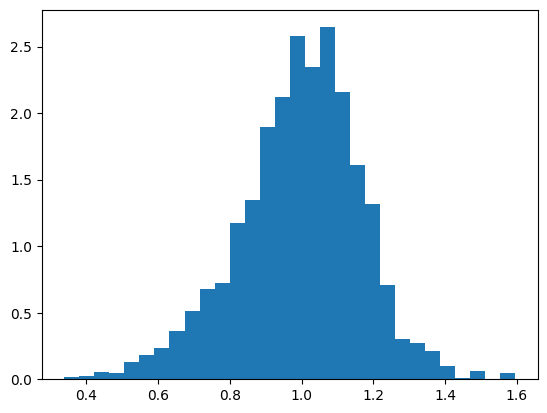

In [52]:
_,_,dls,prior=get_samples_from_event(filtered_files[2])
dl_rwt=np.random.choice(dls, p=prior/np.sum(prior), size=10000)

plt.hist(dl_rwt, bins=30, density=True);

('chi_2_in_plane', 'geocent_time', 'recalib_H1_frequency_2', 'luminosity_distance', 'recalib_H1_amplitude_4', 'tilt_1', 'recalib_H1_amplitude_5', 'L1_time', 'recalib_H1_amplitude_7', 'chirp_mass_source', 'recalib_H1_phase_0', 'spin_2z', 'H1_matched_filter_snr', 'recalib_L1_amplitude_8', 'network_precessing_snr', 'H1_optimal_snr', 'cos_tilt_2_infinity', 'tilt_1_infinity', 'zenith', 'redshift', 'recalib_H1_phase_1', 'recalib_L1_amplitude_1', 'recalib_L1_phase_0', 'final_mass_non_evolved', 'cos_tilt_2', 'spin_2z_infinity', 'chirp_mass', 'a_2', 'recalib_H1_frequency_3', 'spin_2x', 'peak_luminosity', 'recalib_H1_frequency_9', 'recalib_L1_phase_5', 'phase', 'phi_jl', 'network_matched_filter_snr', 'recalib_L1_amplitude_2', 'chi_eff_infinity', 'beta', 'recalib_H1_amplitude_6', 'recalib_H1_phase_9', 'recalib_L1_amplitude_5', 'total_mass', 'phi_1', 'phi_2', 'chi_1_in_plane', 'tilt_2', 'recalib_H1_frequency_4', 'final_mass_source_non_evolved', 'recalib_H1_frequency_1', 'recalib_H1_frequency_7', '

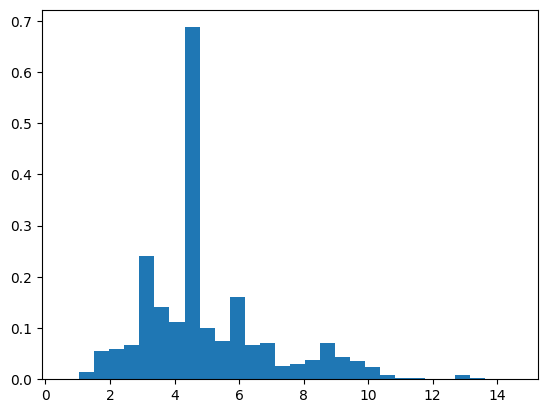

In [53]:
_,_,dls,prior=get_samples_from_event(filtered_files[-2])
dl_rwt=np.random.choice(dls, p=(prior/np.sum(prior)), size=10000)

plt.hist(dl_rwt, bins=30, density=True);

In [20]:
sel_input='../runs/samples-rpo4a_v2_20250503133839UTC-1366933504-23846400.hdf'
(m1, q, z, a1, a2, cos_tilt1, cos_tilt2, pdraw, ndraw) = weighting.extract_selection_samples(
                                                sel_input,nsamp=None, desired_pop_wt=None)

/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'cwb-bbh_bandwidth'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'cwb-bbh_central_freq'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'cwb-bbh_central_rec_time'; it does not match the pattern ``^[a-zA-Z_][a-z

### Errors

In [14]:
def get_X_logmc(M, SNR, sigma_M):
    """
    Take chirp mass, SNR, and upper and lower bounds on chirp mass.
    Propogate those bounds to log chirp mass bounds
    solve for the linear factor we would use to go from SNR to sigma_log_mc

    Also works for log chirp mass!
    """
    sigma_M=jnp.array(sigma_M)
    log_mc=jnp.log(M)
    sigma_log_mc=np.mean(sigma_M/M) #propogate error and collapse to symmetric errors 
    return SNR*sigma_log_mc  #sigma_log_mc= X/SNR

def get_X_q(SNR, sigma_q):
    """
    solve for the linear factor we would use to go from SNR to sigma_q
    This is old, we now use log_q error
    """
    sigma_q=np.mean(sigma_q) #collapse to symmetric
    return SNR*sigma_q #sigma_q= X/SNR


In [99]:
# Event data: (SNR, M, [lower_error, upper_error])
# all 35 events here: https://gwosc.org/eventapi/html/GWTC-3-confident/
events = [(4.5, 15.0, [29.5, 4.0]),
    (10.3, 8.75, [0.62, 0.55]),
    (17.8, 6.6, [2.4, 2.0]),
    (4.7, 34, [44, 18]),
    (7.8, 17.5, [3.5, 3.0]),
    (10.8, 23.4, [4.7, 3.0]),
    (12.5, 14.2, [1.5, 1.4]),
    (20.0, 31.1, [3.3, 2.7]),
    (8.5, 28.2, [7.3, 5.1]),
    (7.2, 62, [23, 15]),
    (10.7, 27.6, [5.6, 3.8]),
    (8.1, 32.9, [9.3, 8.5]),
    (8.4, 6.56, [0.38, 0.40]),
    (9.6, 26.7, [6.0, 4.2]),
    (7.4, 19.8, [10.5, 5.2]),
    (10.8, 27.7, [3.7, 3.1]),
    (10.8, 7.49, [0.24, 0.2]),
    (26.8, 27.2, [2.1, 2.3]),
    (10.6, 32.0, [7.5, 5.5]),
    (11.3, 2.43, [0.05, 0.07]),
    (19.8, 27.4, [2.6, 2.1]),
    (10.4, 36.5, [8.2, 5.6]),
    (12.5, 33.8, [7.1, 5.0]),
    (9.1, 4.31, [0.12, 0.17]),
    (18.6, 8.33, [0.22, 0.19]),
    (11.2, 18.4, [2.2, 1.7]),
    (17.4, 8.56, [0.41, 0.28]),
    (8.9, 19.8, [3.6, 3.2]),
    (13.1, 7.31, [0.43, 0.28]),
    (9.2, 29.9, [11.7, 9.1]),
    (8.3, 8.65, [0.95, 0.71]),
    (7.9, 10.7, [1.1, 1.0]),
    (17.3, 47.5, [9.6, 7.5]),
    (9.7, 7.82, [0.61, 0.45]),
    (8.9, 8.34, [0.66, 0.57])]

Xs_1 = [get_X_logmc(M, SNR, errors) for SNR, M, errors in events]

print("Mean X:", np.mean(Xs_1))
print("Std X:", np.std(Xs_1))

Mean X: 1.767974784089777
Std X: 1.3006138540035586


In [100]:
events_q= [(4.5, 0.3, [0.7, 0.7]),
(10.3, 0.6, [0.4, 0.4]),
(17.8, 0.8, [0.2, 0.2]),
(4.7, 0.4, [0.8, 0.8]),
(7.8, 0.5, [0.3, 0.3]),
(10.8, 0.5, [0.2, 0.2]),
(12.5, 0.7, [0.2, 0.2]),
(20.0, 0.8, [0.2, 0.2]),
(8.5, 0.7, [0.3, 0.3]),
(7.2, 0.7, [0.4, 0.4]),
(10.7, 0.7, [0.3, 0.3]),
(8.1, 0.6, [0.4, 0.4]),
(8.4, 0.117427385892116, [0.0347841574263123, 0.0347841574263123]),
(9.6, 0.8, [0.3, 0.3]),
(7.4, 0.2, [0.3, 0.3]),
(10.8, 0.7, [0.2, 0.2]),
(10.8, 0.7, [0.2, 0.2]),
(26.8, 0.8, [0.2, 0.2]),
(10.6, 0.8, [0.3, 0.3]),
(11.3, 0.244067796610169, [0.133543137064012, 0.133543137064012]),
(19.8, 0.8, [0.2, 0.2]),
(10.4, 0.7, [0.3, 0.3]),
(12.5, 0.8, [0.3, 0.3]),
(9.1, 0.037620578778135, [0.00367611097618323, 0.00367611097618323]),
(18.6, 0.6, [0.2, 0.2]),
(11.2, 0.7, [0.2, 0.2]),
(17.4, 0.7, [0.2, 0.2]),
(8.9, 0.7, [0.3, 0.3]),
(13.1, 0.6, [0.2, 0.2]),
(9.2, 0.5, [0.4, 0.4]),
(8.3, 0.7, [0.3, 0.3]),
(7.9, 0.2, [0.1, 0.1]),
(17.3, 0.7, [0.2, 0.2]),
(9.7, 0.7, [0.2, 0.2]),
(8.9, 0.7, [0.3, 0.3])]



Xs_q = [get_X_q(SNR, errors) for SNR, _, errors in events_q]
SNRS=[]
for i in range(len(events_q)):
    SNRS.append(events_q[i][0])
print("Mean X:", np.mean(Xs_q)) 
print("Std X:", np.std(Xs_q))

Mean X: 2.7958479137453605
Std X: 1.0628760418098722


### LIGO way

In [14]:
import weighting
import h5py
from astropy.cosmology import Planck18
import jax.scipy.special as jss
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

In [15]:
reload(weighting)

<module 'weighting' from '/mnt/home/amoran/GW_pop_cosmo_inference/src/weighting.py'>

In [68]:
#('/home/reed.essick/rates+pop/o3-sensitivity-estimates/LIGO-T2100113-v11/endo3_bbhpop-LIGO-T2100113-v11.hdf5', nsamp=None, desired_pop_wt=None)
m1, q, z, a1, a2, cos_tilt1, cos_tilt2, pdraw, ndraw = weighting.sel_samples_mock('../endo3_bbhpop-LIGO-T2100113-v12.hdf5', 
                                                                                  detectors=detectors, SNR=8, 
                                                                                  sensitivity='o3_PSD',  SNR_load=True,
                                                                                  SNR_write=False,  SNR_file='LIGO_SNR_1222.txt')
df = pd.DataFrame({'m1': m1, 'q': q, 'z': z, 'a1': a1, 'a2':a2, 'cos_tilt_1': cos_tilt1, 'cos_tilt_2': cos_tilt2, 'pdraw_m1sqz': pdraw, 'ndraw': ndraw}) 

In [70]:
df['dm1sz_dm1ddl'] = 1/ ((1+df['z'].values))*cosmo.ddL_dz(df['z'].values)
# weighting.dm1sz_dm1ddl(df['z'])#gives us factor to go soruce to detector frame mass, and z to dL in prior
df.to_hdf('./selection_samples_o3_1230.h5', 'samples')

/tmp/ipykernel_1659843/2770026045.py:3: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df.to_hdf('./selection_samples_o3_1230.h5', 'samples')
